# 04 · Réglage des hyperparamètres et contrôle du sur-apprentissage

**Question : comment régler LightGBM sans sur-apprendre ?**

Stratégie :

1. **validation croisée temporelle** (`TimeSeriesSplit`) : chaque pli entraîne sur le passé et valide sur la période suivante ;
2. une **petite grille** sur les paramètres qui contrôlent la complexité (`num_leaves`, `min_child_samples`) ;
3. **early stopping** pour choisir le nombre d'arbres ;
4. chaque essai est **enregistré dans MLflow** (run parent `tuning`, un run enfant par combinaison) ;
5. les paramètres retenus sont reportés dans `params.yaml`, puis `dvc repro` / la CI réentraînent.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({"figure.figsize": (12, 4), "axes.grid": True, "grid.alpha": 0.3})

import itertools

import mlflow
from lightgbm import early_stopping
from sklearn.model_selection import TimeSeriesSplit

from src.config import configure_mlflow, load_params
from src.data import load_dataset, temporal_split
from src.features import FEATURE_COLUMNS
from src.models import lightgbm, score

params = load_params()
fit, validation, test = temporal_split(load_dataset(), params["split"])
X, y = FEATURE_COLUMNS, "consommation_mw"

# Les 4 dernières années du train suffisent pour régler, et gardent le temps de calcul raisonnable.
tuning_data = fit[fit["timestamp"] >= fit["timestamp"].max() - pd.DateOffset(years=4)].reset_index(drop=True)
folds = list(TimeSeriesSplit(n_splits=4, test_size=48 * 60).split(tuning_data))
print(f"{len(tuning_data):,} lignes, {len(folds)} plis de validation de 60 jours")

70,097 lignes, 4 plis de validation de 60 jours


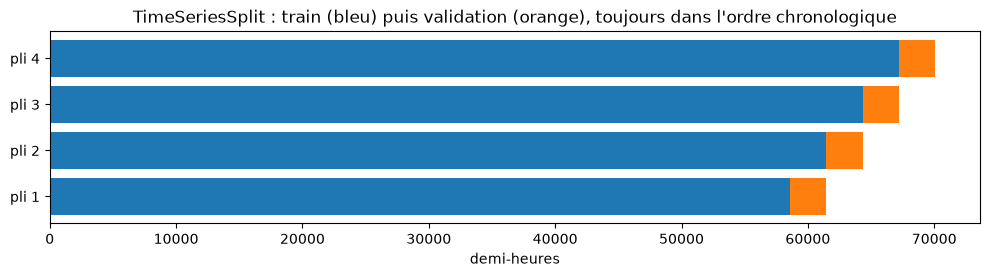

In [2]:
fig, ax = plt.subplots(figsize=(12, 2.5))
for index, (train_index, valid_index) in enumerate(folds):
    ax.barh(index, len(train_index), color="tab:blue")
    ax.barh(index, len(valid_index), left=train_index[-1], color="tab:orange")
ax.set(title="TimeSeriesSplit : train (bleu) puis validation (orange), toujours dans l'ordre chronologique", yticks=range(len(folds)), yticklabels=[f"pli {i + 1}" for i in range(len(folds))], xlabel="demi-heures")
ax.grid(False);

## Grille de recherche avec validation croisée temporelle

In [3]:
grid = {"num_leaves": [15, 31, 63, 127], "min_child_samples": [20, 100]}
base = {**params["lightgbm"], "learning_rate": 0.1}  # taux plus élevé pendant la recherche, pour aller vite


def cross_validate(candidate: dict) -> dict:
    scores = []
    for train_index, valid_index in folds:
        train, valid = tuning_data.iloc[train_index], tuning_data.iloc[valid_index]
        model = lightgbm(candidate).fit(
            train[X], train[y], eval_X=valid[X], eval_y=valid[y], eval_metric="rmse",
            callbacks=[early_stopping(candidate["early_stopping_rounds"], verbose=False)],
        )
        scores.append({"train_rmse": score(train[y], model.predict(train[X]))["rmse"],
                       "cv_rmse": score(valid[y], model.predict(valid[X]))["rmse"],
                       "trees": model.best_iteration_})
    scores = pd.DataFrame(scores)
    return {"cv_rmse": scores["cv_rmse"].mean(), "cv_rmse_std": scores["cv_rmse"].std(),
            "train_rmse": scores["train_rmse"].mean(), "trees": scores["trees"].mean()}


configure_mlflow()
results = []
with mlflow.start_run(run_name="tuning"):
    mlflow.set_tag("stage", "tuning")
    for num_leaves, min_child_samples in itertools.product(grid["num_leaves"], grid["min_child_samples"]):
        candidate = {**base, "num_leaves": num_leaves, "min_child_samples": min_child_samples}
        with mlflow.start_run(run_name=f"leaves={num_leaves}_child={min_child_samples}", nested=True):
            metrics = cross_validate(candidate)
            mlflow.log_params(candidate)
            mlflow.log_metrics(metrics)
        results.append({"num_leaves": num_leaves, "min_child_samples": min_child_samples, **metrics})

results = pd.DataFrame(results).sort_values("cv_rmse")
results

,num_leaves,min_child_samples,cv_rmse,cv_rmse_std,train_rmse,trees
1,15,100,2319.575542,730.597228,1526.429141,345.75
0,15,20,2333.439571,739.016017,1496.634594,292.00
3,31,100,2365.597543,801.443230,1466.085228,253.00
4,63,20,2390.157884,788.304856,1228.437309,166.75
7,127,100,2390.609484,743.960086,1198.946777,143.50
2,31,20,2401.032514,823.187790,1388.889089,260.25
5,63,100,2410.021388,743.484710,1331.193765,178.50
6,127,20,2463.693461,828.163785,1053.709639,187.75


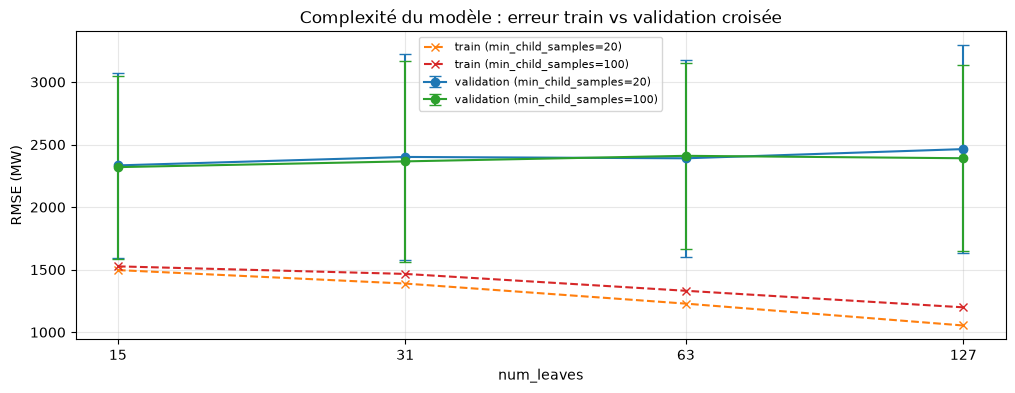

In [4]:
fig, ax = plt.subplots()
for min_child_samples, group in results.sort_values("num_leaves").groupby("min_child_samples"):
    ax.errorbar(group["num_leaves"], group["cv_rmse"], yerr=group["cv_rmse_std"], marker="o", capsize=4, label=f"validation (min_child_samples={min_child_samples})")
    ax.plot(group["num_leaves"], group["train_rmse"], marker="x", linestyle="--", label=f"train (min_child_samples={min_child_samples})")
ax.set(xscale="log", xticks=grid["num_leaves"], xticklabels=grid["num_leaves"], title="Complexité du modèle : erreur train vs validation croisée", xlabel="num_leaves", ylabel="RMSE (MW)")
ax.minorticks_off()
ax.legend(fontsize=8);

**Lecture du graphique (compromis biais / variance) :**

- l'erreur **train** baisse quand le modèle se complexifie (plus de feuilles, moins d'observations minimum par feuille) ;
- l'erreur de **validation croisée**, elle, ne s'améliore pas : la complexité supplémentaire ne sert qu'à mieux « réciter » le passé ;
- l'**écart train / validation grandit** avec la complexité : c'est la signature du sur-apprentissage ;
- les écarts entre combinaisons (≈ 100 MW) sont bien plus petits que la variabilité entre plis (barres d'erreur ≈ ±700 MW) : aucune n'est significativement meilleure.

→ On retient le modèle **le plus simple et le plus régularisé** (`num_leaves=15`, `min_child_samples=100`), qui a aussi le meilleur score moyen.

## Early stopping : combien d'arbres ?

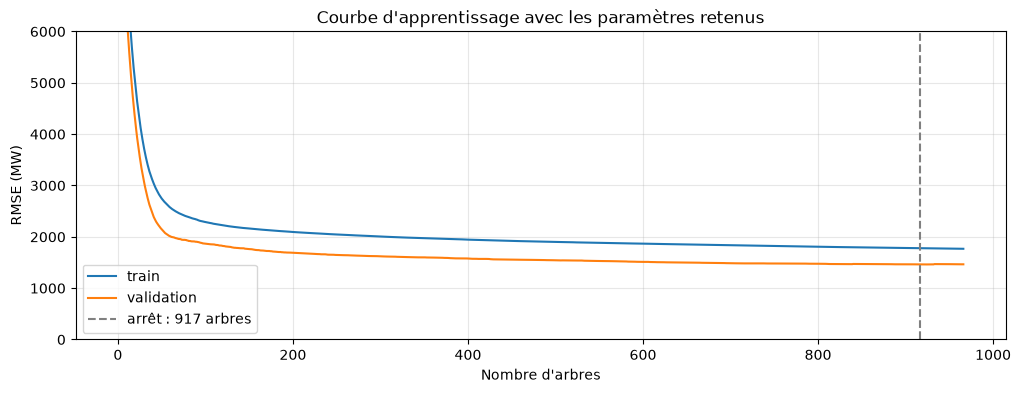

In [5]:
best = results.iloc[0]
chosen = {**params["lightgbm"], "num_leaves": int(best["num_leaves"]), "min_child_samples": int(best["min_child_samples"])}
model = lightgbm(chosen).fit(
    fit[X], fit[y], eval_X=(fit[X], validation[X]), eval_y=(fit[y], validation[y]),
    eval_names=["train", "validation"], eval_metric="rmse",
    callbacks=[early_stopping(chosen["early_stopping_rounds"], verbose=False)],
)
fig, ax = plt.subplots()
for name, curve in model.evals_result_.items():
    ax.plot(curve["rmse"], label=name)
ax.axvline(model.best_iteration_, color="grey", linestyle="--", label=f"arrêt : {model.best_iteration_} arbres")
ax.set(title="Courbe d'apprentissage avec les paramètres retenus", xlabel="Nombre d'arbres", ylabel="RMSE (MW)", ylim=(0, 6000))
ax.legend();

L'early stopping arrête l'ajout d'arbres quand l'erreur de validation ne s'améliore plus pendant 50 itérations : au-delà, on ne réduirait plus que l'erreur d'entraînement.

*Pourquoi la validation est-elle sous le train ?* La RMSE est en MW : la période de validation (printemps) a une consommation plus basse, donc des erreurs absolues plus faibles que le train, qui contient tous les hivers. Pour juger le sur-apprentissage, on compare des erreurs **sur des périodes comparables** : c'est ce que fait la validation croisée ci-dessus.

In [6]:
print("Paramètres retenus à reporter dans params.yaml :")
{key: chosen[key] for key in ["learning_rate", "num_leaves", "min_child_samples", "colsample_bytree", "reg_lambda"]}

Paramètres retenus à reporter dans params.yaml :


{'learning_rate': 0.05,
 'num_leaves': 15,
 'min_child_samples': 100,
 'colsample_bytree': 0.9,
 'reg_lambda': 0.0}